In [1]:
# ============================================
# AI Stock Price Predictor
# Internship Project using Machine Learning
# ============================================


In [3]:
# =========================
# Import Libraries
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
# =========================
#  Load Dataset
# =========================

data = pd.read_csv(
    r"C:\Users\HP\Downloads\nflx_2014_2023.csv"
)

data.head()


,date,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
0,2014-01-02,52.401428,52.511429,51.542858,51.831429,12325600,34.729664,49.183584,-89.573201,-131.288579,50.112828,50.235157,46.385428,46.650698,0.751929,52.607357,1.052857,1.161182,1.247748,51.871429
1,2014-01-03,52.000000,52.495712,51.842857,51.871429,10817100,35.587886,49.457208,-65.820581,-103.026189,50.228771,50.299327,46.537571,46.754726,0.624259,52.656143,0.664283,1.090197,1.206072,51.367142
2,2014-01-06,51.889999,52.044285,50.475716,51.367142,15501500,29.820674,46.087900,-121.472559,-139.640566,50.312571,50.341203,46.680971,46.846621,0.476890,52.666928,1.568569,1.158535,1.231965,48.500000
3,2014-01-07,49.684284,49.698570,48.152859,48.500000,36167600,14.371863,32.522091,-206.762171,-238.029120,50.336228,50.268997,46.791957,46.879558,0.127277,52.560214,3.214283,1.452214,1.373559,48.712856
4,2014-01-08,48.104286,49.425713,48.074287,48.712856,20001100,18.049045,34.073549,-117.836707,-180.766801,50.373257,50.207969,46.917071,46.916075,-0.131106,52.455357,1.351426,1.437815,1.371978,48.150002


In [7]:
# =========================
#  Dataset Shape
# =========================

print("Dataset Shape :")

print(data.shape)


Dataset Shape :
(2516, 20)


In [9]:

# =========================
# Column Names
# =========================

print(data.columns)


Index(['date', 'open', 'high', 'low', 'close', 'volume', 'rsi_7', 'rsi_14',
       'cci_7', 'cci_14', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 'macd',
       'bollinger', 'TrueRange', 'atr_7', 'atr_14', 'next_day_close'],
      dtype='object')


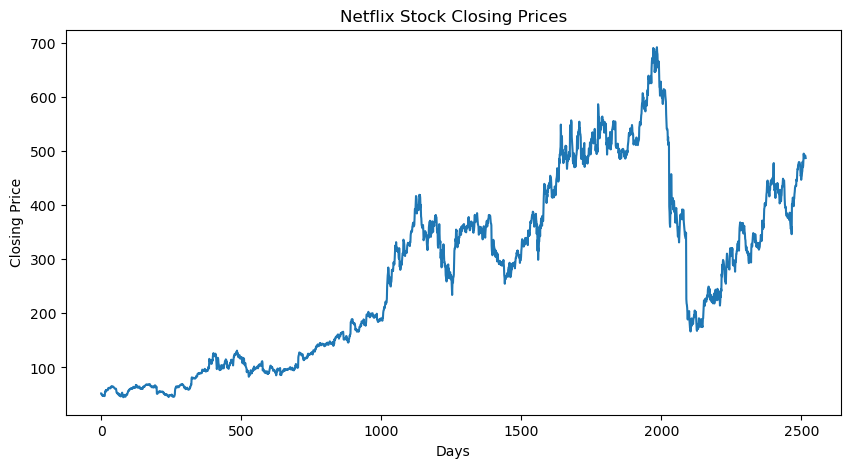

In [19]:
# =========================
# Closing Price Graph
# =========================

plt.figure(figsize=(10,5))

plt.plot(data['close'])

plt.title("Netflix Stock Closing Prices")

plt.xlabel("Days")

plt.ylabel("Closing Price")

plt.show()

In [21]:
# =========================
# Keep Important Column
# =========================

data = data[['close']]


In [23]:
# =========================
#  Create Prediction Column
# =========================

data['Prediction'] = data['close'].shift(-30)

data.head()

,close,Prediction
0,51.831429,62.215714
1,51.871429,62.407143
2,51.367142,61.175713
3,48.500000,62.135715
4,48.712856,61.747143


In [25]:
# =========================
# Create Features and Labels
# =========================

X = data[['close']][:-30]

y = data['Prediction'][:-30]

In [27]:
# =========================
# Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [29]:
# =========================
# Train Model
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [33]:
# =========================
# Model Accuracy
# =========================

score = model.score(X_test, y_test)

print("Model Accuracy :", score)

Model Accuracy : 0.916173958644884


In [35]:
# =========================
# Predict Future Prices
# =========================

future = data[['close']].tail(30)

prediction = model.predict(future)

print("Predicted Future Prices :")

print(prediction)

Predicted Future Prices :
[464.73229645 463.73252465 471.96134944 472.42278961 475.35477859
 476.85442283 476.47952571 476.31609023 474.57611808 471.48069362
 463.56908821 452.18716218 453.38880173 445.29457403 450.36067582
 452.05259393 457.94543912 460.93510391 477.25818622 467.50084995
 469.64458549 483.16062434 491.71629221 486.18875025 488.43821565
 483.77587821 488.03448111 488.61127482 487.38079688 483.8912308 ]


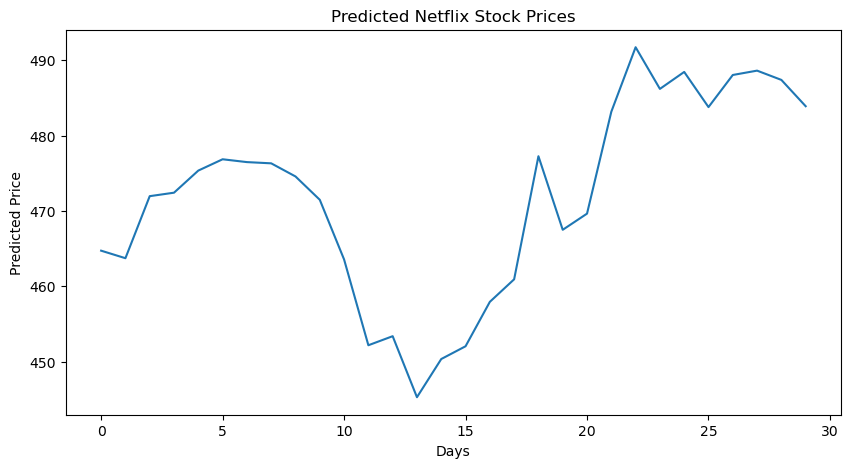

In [37]:
# =========================
# Prediction Graph
# =========================

plt.figure(figsize=(10,5))

plt.plot(prediction)

plt.title("Predicted Netflix Stock Prices")

plt.xlabel("Days")

plt.ylabel("Predicted Price")

plt.show()